In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
!pip install snowflake-connector-python pandas scikit-learn

In [40]:
import snowflake.connector

In [41]:
conn=snowflake.connector.connect(
    user="XXXXXXX",
    password="XXXXXXXXXXX",
    account="XXXXXXXX",
    database="DB1",
    schema="PUBLIC",
    warehouse="COMPUTE_WH")

In [42]:
query='SELECT * FROM "DB1"."PUBLIC"."WATER"'

In [43]:
df=pd.read_sql_query(query,conn)

C:\Users\dhanu\AppData\Local\Temp\ipykernel_33160\2537423350.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,conn)


In [44]:
conn.close()

In [45]:
df.head()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [46]:
df.tail()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
3271,4.668102,193.681736,47580.99160,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.17706,7.509306,NaN,327.459761,16.140368,78.698446,2.309149,1


In [47]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690300,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833605,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762125,8.114887,359.950170,481.792305,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [49]:
df.shape

(3276, 10)

In [50]:
df.size

32760

In [51]:
df.isnull().sum()

PH                 491
HARDNESS             0
SOLIDS               0
CHLORAMINES          0
SULFATE            781
CONDUCTIVITY         0
ORGANIC_CARBON       0
TRIHALOMETHANES    162
TURBIDITY            0
POTABILITY           0
dtype: int64

In [52]:
from sklearn.impute import SimpleImputer

In [53]:
si=SimpleImputer(strategy="mean")

In [54]:
df[["PH"]]=si.fit_transform(df[["PH"]])
df[["SULFATE"]]=si.fit_transform(df[["SULFATE"]])
df[["TRIHALOMETHANES"]]=si.fit_transform(df[["TRIHALOMETHANES"]])

In [55]:
df.isnull().sum()

PH                 0
HARDNESS           0
SOLIDS             0
CHLORAMINES        0
SULFATE            0
CONDUCTIVITY       0
ORGANIC_CARBON     0
TRIHALOMETHANES    0
TURBIDITY          0
POTABILITY         0
dtype: int64

In [62]:
cols=df.columns.tolist()
import math
n=len(cols)
rows=math.ceil(n/3)

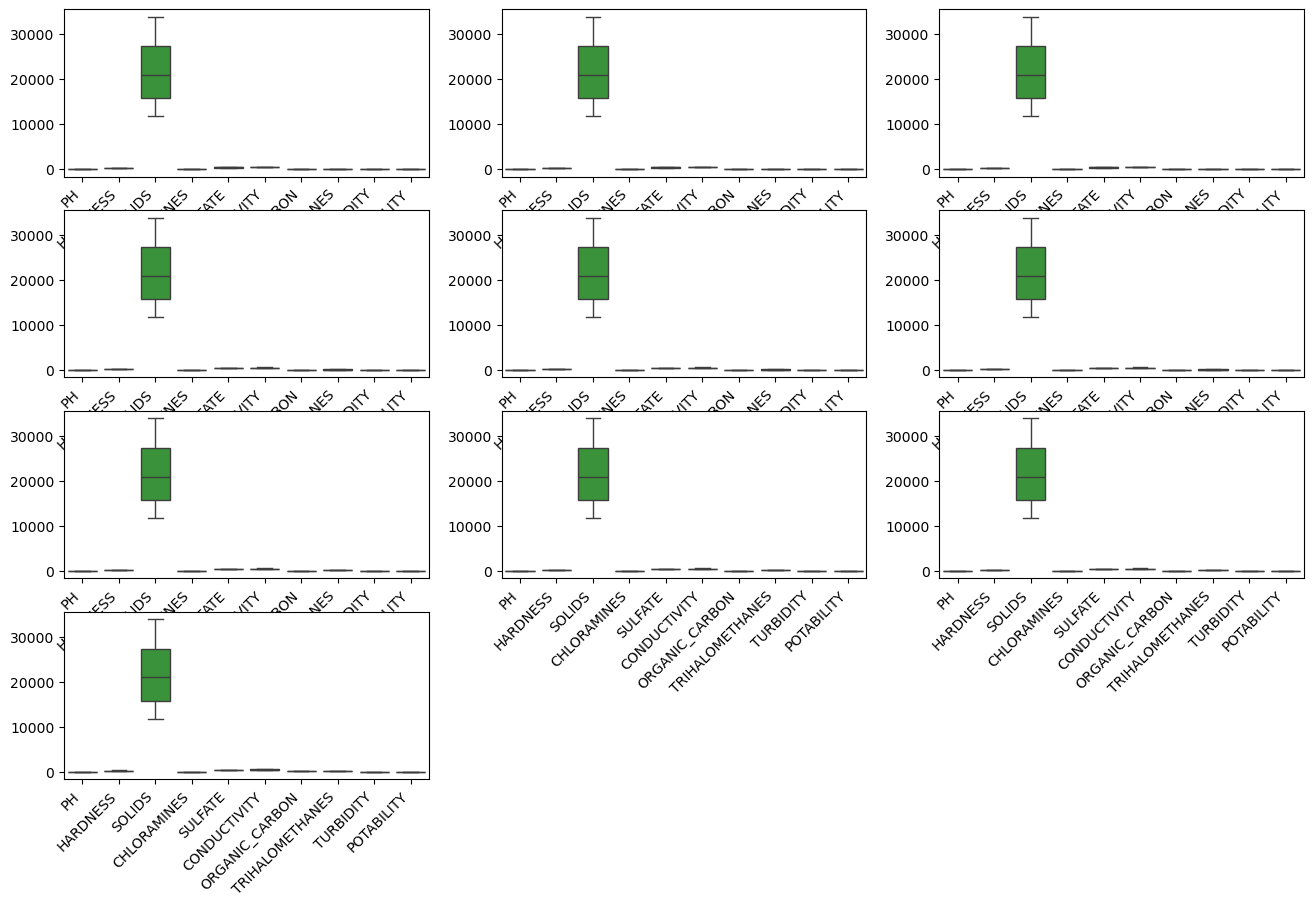

In [63]:
plt.figure(figsize=(16,10))
for i in range(len(cols)):
    plt.subplot(rows,3,i+1)
    sns.boxplot(df[cols])
    plt.xticks(rotation=45,ha="right")

In [64]:
cols=["PH","HARDNESS","SOLIDS","CHLORAMINES","SULFATE","CONDUCTIVITY","ORGANIC_CARBON","TRIHALOMETHANES","TURBIDITY","POTABILITY"]

In [65]:
from scipy.stats.mstats import winsorize

In [66]:
for i in range(len(cols)):
    df[cols[i]]=winsorize(df[cols[i]],limits=(0.1,0.1))

In [67]:
cols=df.columns.tolist()
import math
n=len(cols)
rows=math.ceil(n/3)

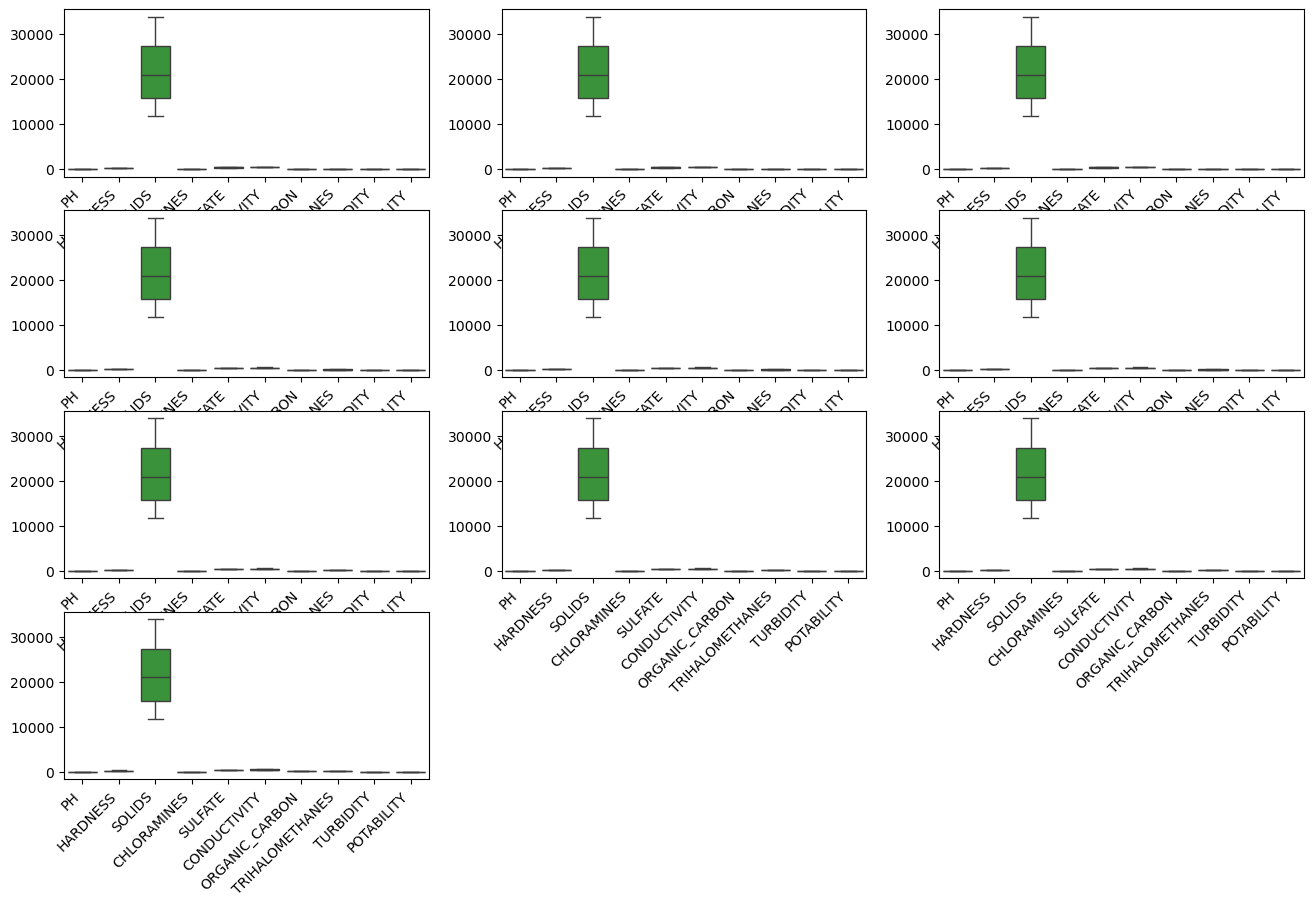

In [68]:
plt.figure(figsize=(16,10))
for i in range(len(cols)):
    plt.subplot(rows,3,i+1)
    sns.boxplot(df[cols])
    plt.xticks(rotation=45,ha="right")

In [86]:
cols1=["PH","HARDNESS","SOLIDS","CHLORAMINES","SULFATE","CONDUCTIVITY","ORGANIC_CARBON","TRIHALOMETHANES","TURBIDITY"]
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df[cols1]=sc.fit_transform(df[cols1])

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [89]:
X=df[cols1]
y=df["POTABILITY"]

In [90]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [91]:
s=SVC(kernel="linear")
s.fit(X_train,y_train)

SVC(kernel='linear')

In [92]:
y_pred=s.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.6280487804878049
